In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/airbnb_cleaned.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 48392
Columns: 20


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,price_per_review,is_private_room,is_entire_home,has_reviews
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,14.900000,1,0,1
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,4.891304,0,1,1
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,No Review,0.00,1,365,150.000000,1,0,0
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,0.328413,0,1,1
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,8.000000,0,1,1


In [2]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,price_per_review,is_private_room,is_entire_home,has_reviews
count,4.839200e+04,4.839200e+04,48392.000000,48392.000000,48392.000000,48392.000000,48392.000000,48392.000000,48392.000000,48392.000000,48392.000000,48392.000000,48392.000000,48392.000000
mean,1.901519e+07,6.757340e+07,40.728902,-73.951924,137.329145,6.980472,23.419449,1.096973,7.180567,112.014507,49.003203,0.459373,0.516842,0.796971
std,1.097511e+07,7.856254e+07,0.054628,0.046170,103.012234,20.296888,44.706687,1.601271,33.100476,131.208717,82.192412,0.498352,0.499721,0.402258
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,10.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.074603,0.000000,0.000000,0.000000
25%,9.475404e+06,7.820478e+06,40.689940,-73.982843,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000,4.076923,0.000000,0.000000,1.000000
50%,1.967483e+07,3.080866e+07,40.722885,-73.955480,105.000000,3.000000,5.000000,0.380000,1.000000,44.000000,17.000000,0.000000,1.000000,1.000000
75%,2.913264e+07,1.074344e+08,40.763160,-73.935950,175.000000,5.000000,24.000000,1.600000,2.000000,224.000000,55.500000,1.000000,1.000000,1.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,795.000000,1250.000000,629.000000,58.500000,327.000000,365.000000,795.000000,1.000000,1.000000,1.000000


In [3]:
room_price = df.groupby("room_type")["price"].mean().sort_values(ascending=False)

room_price

room_type
Entire home/apt    188.832034
Private room        83.169411
Shared room         64.203301
Name: price, dtype: float64

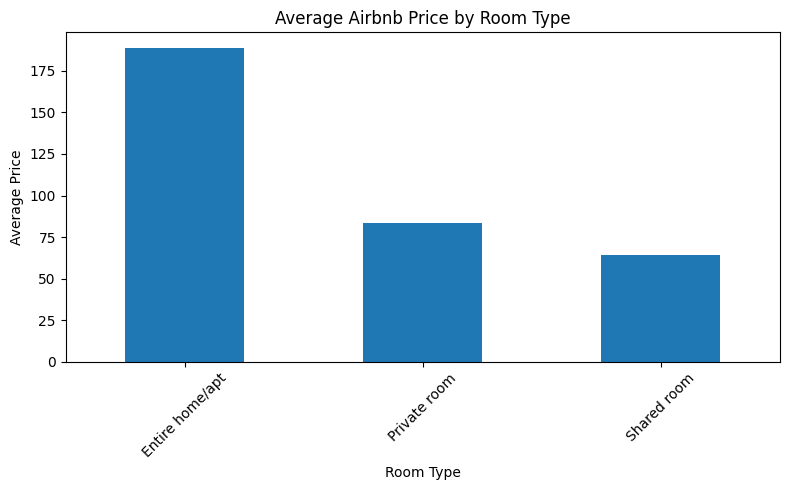

In [4]:
room_price.plot(kind="bar", figsize=(8, 5))
plt.title("Average Airbnb Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
top_neighborhoods = (
    df.groupby("neighbourhood")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_neighborhoods

neighbourhood
Woodrow               700.000000
Tribeca               292.400000
NoHo                  276.246753
Neponsit              274.666667
Flatiron District     258.162162
Midtown               252.113195
Willowbrook           249.000000
SoHo                  228.139881
West Village          224.897019
Financial District    215.745257
Name: price, dtype: float64

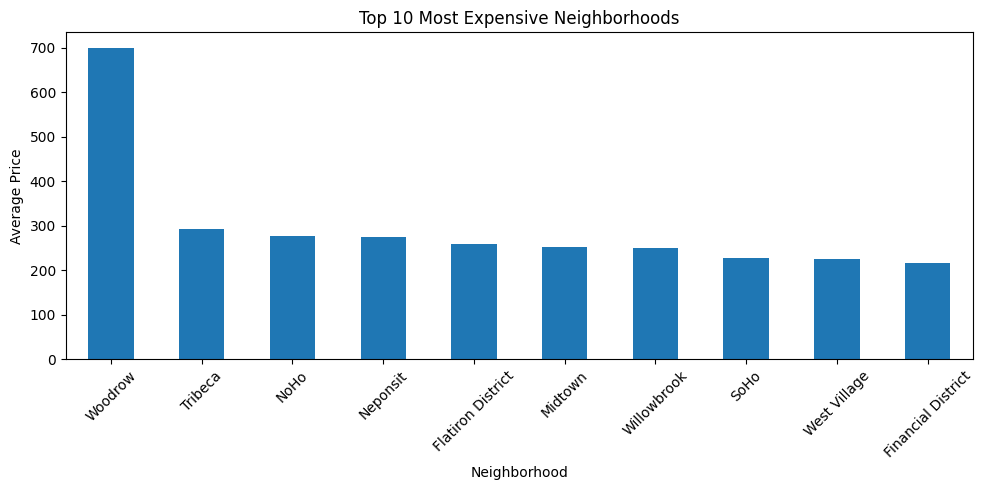

In [6]:
top_neighborhoods.plot(kind="bar", figsize=(10, 5))
plt.title("Top 10 Most Expensive Neighborhoods")
plt.xlabel("Neighborhood")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
borough_count = df["neighbourhood_group"].value_counts()

borough_count

neighbourhood_group
Manhattan        21294
Brooklyn         19992
Queens            5650
Bronx             1087
Staten Island      369
Name: count, dtype: int64

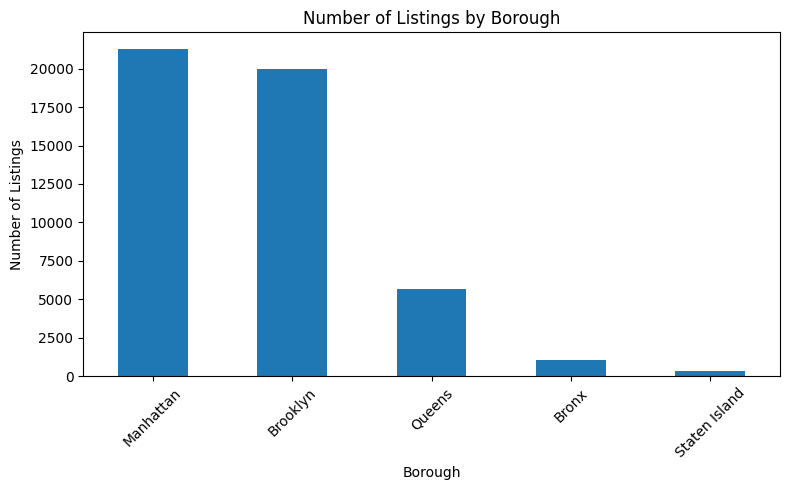

In [8]:
borough_count.plot(kind="bar", figsize=(8, 5))
plt.title("Number of Listings by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

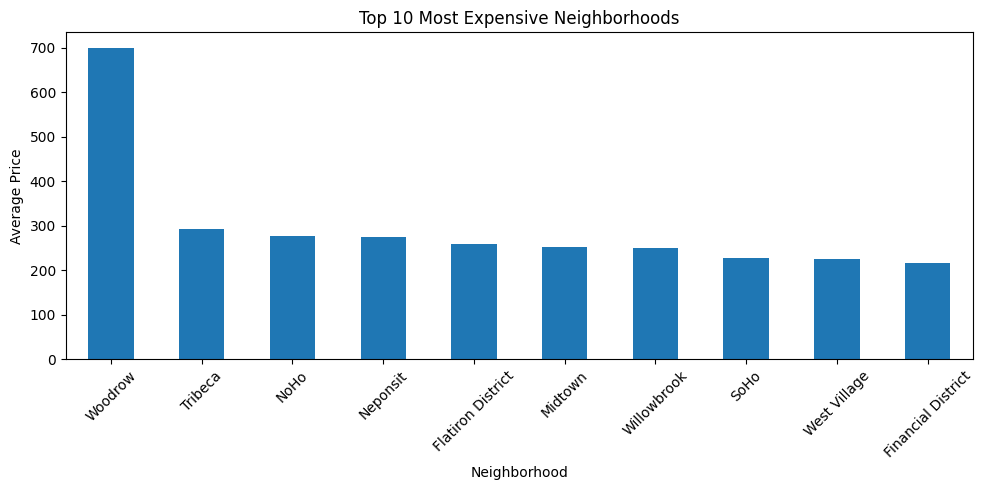

Image saved successfully.


In [9]:
top_neighborhoods.plot(kind="bar", figsize=(10, 5))
plt.title("Top 10 Most Expensive Neighborhoods")
plt.xlabel("Neighborhood")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../images/price_by_neighborhood.png", dpi=300, bbox_inches="tight")
plt.show()

print("Image saved successfully.")

In [ ]:
import matplotlib.pyplot as plt
import os

os.makedirs("../images", exist_ok=True)

# Price distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df[df["price"] <= 500]["price"], bins=80, color="steelblue", edgecolor="white")
ax.set_title("NYC Airbnb Price Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Price ($)")
ax.set_ylabel("Number of Listings")
plt.tight_layout()
plt.savefig("../images/price_distribution.png", dpi=150)
plt.show()

# Average price by borough
fig, ax = plt.subplots(figsize=(8, 5))
borough_avg = df.groupby("neighbourhood_group")["price"].mean().sort_values(ascending=False)
borough_avg.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Average Price by Borough", fontsize=14, fontweight="bold")
ax.set_xlabel("Borough")
ax.set_ylabel("Average Price ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/avg_price_by_borough.png", dpi=150)
plt.show()

# Average price by room type
fig, ax = plt.subplots(figsize=(8, 5))
room_avg = df.groupby("room_type")["price"].mean().sort_values(ascending=False)
room_avg.plot(kind="bar", ax=ax, color="coral", edgecolor="white")
ax.set_title("Average Price by Room Type", fontsize=14, fontweight="bold")
ax.set_xlabel("Room Type")
ax.set_ylabel("Average Price ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/avg_price_by_roomtype.png", dpi=150)
plt.show()